In [5]:
!pip install geopandas rasterio shapely pyproj geemap -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 23.2 MB/s eta 0:00:00


In [6]:
import json, os
KAGGLE_USERNAME = "devisum"
KAGGLE_KEY = "KGAT_2b1dc05b88b7da7479e2223f7d5e84c1"
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
with open(os.path.expanduser("~/.kaggle/kaggle.json"), "w") as f:
    json.dump({"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}, f)
os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)
print("kaggle API ok")

kaggle API ok


In [7]:
import os
!kaggle datasets download -d rishabhsnip/earth-observation-delhi-airshed --unzip -p /content/data
#seeing inside
for root, dirs, files in os.walk("/content/data"):
    for f in files:
        print(os.path.join(root, f))

Streaming output truncated to the last 5000 lines.
/content/data/rgb/28.8354_76.8910.png
/content/data/rgb/28.2266_77.4409.png
/content/data/rgb/28.7855_77.1821.png
/content/data/rgb/28.6091_77.1322.png
/content/data/rgb/28.7178_76.9944.png
/content/data/rgb/28.4057_76.8646.png
/content/data/rgb/28.7266_77.5909.png
/content/data/rgb/28.7090_77.5645.png
/content/data/rgb/28.9556_77.4822.png
/content/data/rgb/28.3178_77.3943.png
/content/data/rgb/28.2679_77.1410.png
/content/data/rgb/28.4057_77.5909.png
/content/data/rgb/28.6557_77.5146.png
/content/data/rgb/28.4590_77.0733.png
/content/data/rgb/28.6590_77.3910.png
/content/data/rgb/28.9556_77.2822.png
/content/data/rgb/28.9766_77.3233.png
/content/data/rgb/28.9057_77.3910.png
/content/data/rgb/28.7767_76.8943.png
/content/data/rgb/28.2178_76.8910.png
/content/data/rgb/28.5443_77.3646.png
/content/data/rgb/28.5766_77.3409.png
/content/data/rgb/28.8556_77.3734.png
/content/data/rgb/28.6766_76.8910.png
/content/data/rgb/28.2943_77.1234.png

In [8]:
import os
import glob
print("top files")
for f in os.listdir("/content/data"):
    print(f)

all_images = glob.glob("/content/data/rgb/*.png")
print(f"total images: {len(all_images)}")
print("\nonly first5 files")
for img in all_images[:5]:
    print(os.path.basename(img))

top files
rgb
delhi_ncr_region.geojson
worldcover_bbox_delhi_ncr_2021.tif
delhi_airshed.geojson
total images: 9216

only first5 files
28.4766_77.5146.png
28.7354_77.5557.png
28.5942_77.1443.png
28.5443_77.0234.png
28.8855_77.6443.png


In [9]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from shapely.geometry import box
import numpy as np
from pyproj import Transformer

delhi_ncr = gpd.read_file("/content/data/delhi_ncr_region.geojson")
delhi_airshed = gpd.read_file("/content/data/delhi_airshed.geojson")
print("CRS:", delhi_ncr.crs)
print("shape:", delhi_ncr.shape)
print(delhi_ncr.head())

CRS: EPSG:4326
shape: (30, 1)
                                            geometry
0  POLYGON ((76.85108 28.22115, 76.85219 28.22098...
1  POLYGON ((77.15903 29.29436, 77.15999 29.29427...
2  MULTIPOLYGON (((77.07565 27.27704, 77.07819 27...
3  POLYGON ((77.97073 28.71104, 77.97089 28.71096...
4  POLYGON ((77.2143 28.78524, 77.21521 28.78514,...


bounds (metres): -39135, 2958988, 252194, 3324410
width : 291.3 km
height: 365.4 km
grid cells created: 35


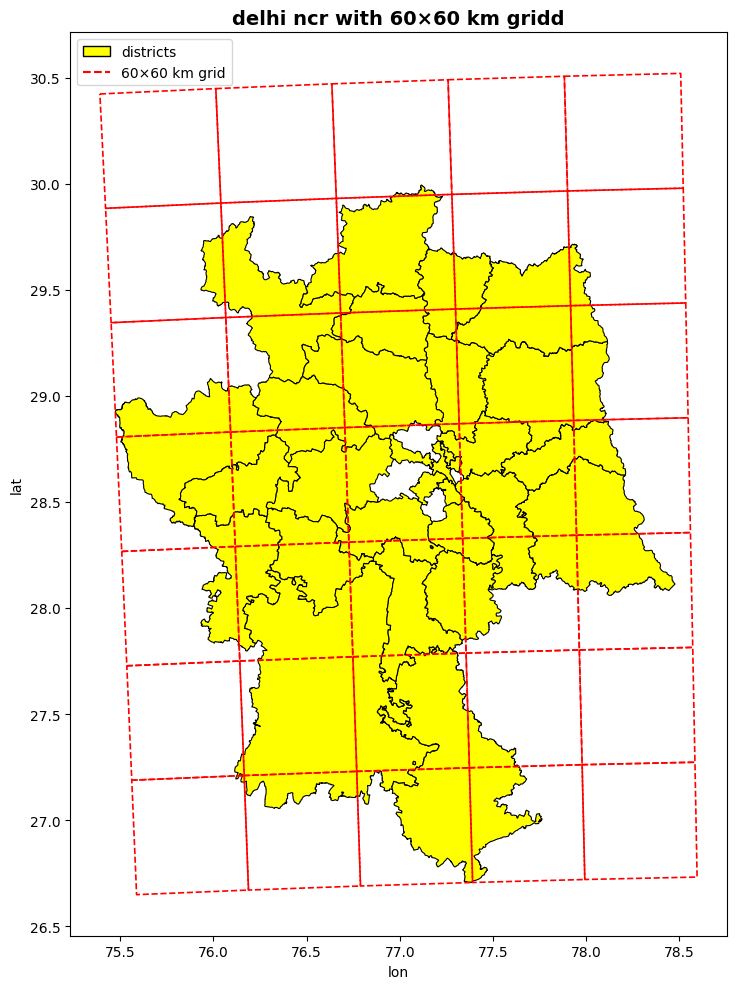

In [10]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from shapely.geometry import box
from pyproj import Transformer

delhi_ncr_proj = delhi_ncr.to_crs("EPSG:32644")
#for bounding box after made for EPSG:32644
minx, miny, maxx, maxy = delhi_ncr_proj.total_bounds
print(f"bounds (metres): {minx:.0f}, {miny:.0f}, {maxx:.0f}, {maxy:.0f}")
print(f"width : {(maxx-minx)/1000:.1f} km")
print(f"height: {(maxy-miny)/1000:.1f} km")

#60 cross 60 grid
cell = 60_000   # 60 km in metres
xs = np.arange(minx, maxx + cell, cell)
ys = np.arange(miny, maxy + cell, cell)

grid_cells = []
for x0 in xs[:-1]:
    for y0 in ys[:-1]:
        grid_cells.append(box(x0, y0, x0 + cell, y0 + cell))

grid = gpd.GeoDataFrame(geometry=grid_cells, crs="EPSG:32644")
print(f"grid cells created: {len(grid)}")

#i reprojected everything back to 4326 coz plotting
grid_4326 = grid.to_crs("EPSG:4326")

fig, ax = plt.subplots(figsize=(10, 10))

delhi_ncr.plot(ax=ax, color="yellow", edgecolor="black", linewidth=0.8)
grid_4326.boundary.plot(ax=ax, color="red", linewidth=1.2, linestyle="--")

ax.set_title("delhi ncr with 60×60 km gridd", fontsize=14, fontweight="bold")
ax.set_xlabel("lon")
ax.set_ylabel("lat")

from matplotlib.lines import Line2D
legend = [
    mpatches.Patch(facecolor="yellow", edgecolor="black", label="districts"),
    Line2D([0], [0], color="red", linestyle="--", label="60×60 km grid")
]
ax.legend(handles=legend, loc="upper left")

plt.tight_layout()
plt.savefig("/content/q1_delhi_ncr_grid.png", dpi=150, bbox_inches="tight")
plt.show()


In [11]:
import pandas as pd
from shapely.geometry import Point

# get coords from filename
records = []
for path in all_images:
    fname = os.path.basename(path)  # example file
    parts = fname.replace(".png", "").split("_")
    lat, lon = float(parts[0]), float(parts[1])
    records.append({"filename": fname, "filepath": path, "lat": lat, "lon": lon})
df = pd.DataFrame(records)
print(f"total images (before filtering): {len(df)}")

# make geodataframe
gdf_points = gpd.GeoDataFrame(
    df,
    geometry=[Point(row.lon, row.lat) for row in df.itertuples()],
    crs="EPSG:4326"
)

# keep only inside delhi-ncr
filtered = gpd.sjoin(gdf_points, delhi_ncr, how="inner", predicate="within")
filtered = filtered.drop_duplicates(subset="filename").reset_index(drop=True)
print(f"images after filtering (inside delhi-ncr): {len(filtered)}")

print(filtered[["filename", "lat", "lon"]].head())

total images (before filtering): 9216
images after filtering (inside delhi-ncr): 8015
              filename      lat      lon
0  28.4766_77.5146.png  28.4766  77.5146
1  28.7354_77.5557.png  28.7354  77.5557
2  28.5942_77.1443.png  28.5942  77.1443
3  28.8855_77.6443.png  28.8855  77.6443
4  28.9854_77.4057.png  28.9854  77.4057


In [12]:
#note this
print(f"total images (before filtering): {len(df)}")
print(f"images inside delhi-ncr: {len(filtered)}")
print(f"images outside (removed): {len(df) - len(filtered)}")
print("grid: 60x60 km , crs: epsg:32644")
print("region crs: epsg:4326")

total images (before filtering): 9216
images inside delhi-ncr: 8015
images outside (removed): 1201
grid: 60x60 km , crs: epsg:32644
region crs: epsg:4326


In [13]:
import rasterio # tiff files
from rasterio.windows import from_bounds
tif_path = "/content/data/worldcover_bbox_delhi_ncr_2021.tif"
with rasterio.open(tif_path) as src:
    print(f"crs : {src.crs}")
    print(f"resolution : {src.res}")
    print(f"dimensions : {src.width} x {src.height} pixels")
    print(f"bounds: {src.bounds}")
    print(f"nodata : {src.nodata}")
    print(f"dtype: {src.dtypes[0]}")
    print(f"bands : {src.count}")
    # checking classes
    sample = src.read(1, window=rasterio.windows.Window(0, 0, 500, 500))
    import numpy as np
    print(f"\nunique esa classes {np.unique(sample)}")

crs : EPSG:4326
resolution : (8.333333333333333e-05, 8.333333333333333e-05)
dimensions : 9602 x 9600 pixels
bounds: BoundingBox(left=76.84991666666667, bottom=28.2, right=77.65008333333334, top=29.0)
nodata : 0.0
dtype: uint8
bands : 1

unique esa classes [ 0 10 20 30 40 50 60 80]


In [14]:
import rasterio
import numpy as np
from scipy import stats

# ── ESA class → simplified category mapping ─────────────────────────────────
ESA_MAP = {
    10: "Vegetation",   # Tree cover
    20: "Vegetation",   # Shrubland
    30: "Vegetation",   # Grassland
    40: "Cropland",     # Cropland
    50: "Built-up",     # Built-up
    60: "Others",       # Bare / sparse vegetation
    70: "Others",       # Snow and ice
    80: "Water",        # Permanent water bodies
    90: "Others",       # Herbaceous wetland
    95: "Others",       # Mangroves
    100: "Others",      # Moss and lichen
}

tif_path = "/content/data/worldcover_bbox_delhi_ncr_2021.tif"

# ── Half-width: 64 pixels × 8.333e-5 deg/pixel ──────────────────────────────
half_deg = 64 * 8.333333e-5   # ~0.005333 degrees

labels      = []
class_codes = []
failed      = 0

with rasterio.open(tif_path) as src:
    for idx, row in filtered.iterrows():
        lat, lon = row["lat"], row["lon"]

        # bounding box around center
        left   = lon - half_deg
        right  = lon + half_deg
        bottom = lat - half_deg
        top    = lat + half_deg

        try:
            window = rasterio.windows.from_bounds(
                left, bottom, right, top,
                transform=src.transform
            )
            patch = src.read(1, window=window)

            # crop/pad to exactly 128×128
            patch = patch[:128, :128]
            if patch.shape[0] < 128 or patch.shape[1] < 128:
                patch = np.pad(patch,
                               ((0, 128 - patch.shape[0]),
                                (0, 128 - patch.shape[1])),
                               mode="edge")

            # remove nodata (0) before mode
            valid = patch[patch > 0]
            if len(valid) == 0:
                labels.append("Others")
                class_codes.append(0)
            else:
                mode_class = int(stats.mode(valid, keepdims=True).mode[0])
                class_codes.append(mode_class)
                labels.append(ESA_MAP.get(mode_class, "Others"))

        except Exception as e:
            labels.append("Others")
            class_codes.append(0)
            failed += 1

filtered = filtered.copy()
filtered["esa_code"]  = class_codes
filtered["label"]     = labels

print(f"Extraction complete ✅")
print(f"Failed patches     : {failed}")
print(f"\nLabel distribution:")
print(filtered["label"].value_counts())
print(f"\nESA code distribution:")
print(filtered["esa_code"].value_counts())

Extraction complete ✅
Failed patches     : 0

Label distribution:
label
Cropland      5471
Built-up      1780
Vegetation     755
Water            7
Others           2
Name: count, dtype: int64

ESA code distribution:
esa_code
40    5471
50    1780
10     343
20     248
30     164
80       7
90       2
Name: count, dtype: int64


Train set : 4809 images
Test set  : 3206  images


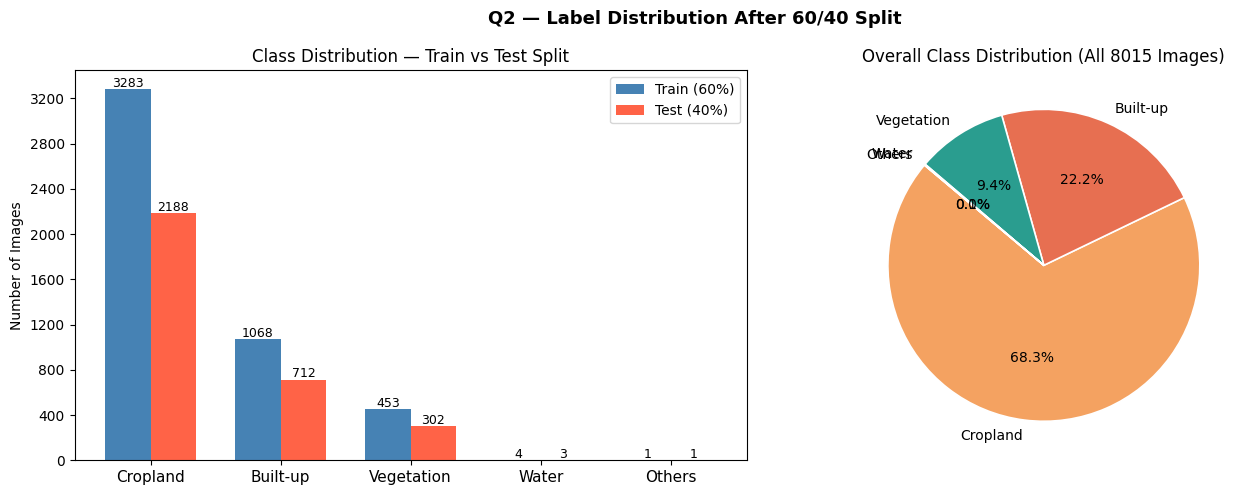

Plot saved ✅


In [15]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── 60/40 split ──────────────────────────────────────────────────────────────
train_df, test_df = train_test_split(
    filtered,
    test_size=0.4,
    random_state=42,
    stratify=filtered["label"]   # keeps class balance in both splits
)

train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Train set : {len(train_df)} images")
print(f"Test set  : {len(test_df)}  images")

# ── Class distribution ────────────────────────────────────────────────────────
classes      = ["Cropland", "Built-up", "Vegetation", "Water", "Others"]
train_counts = [len(train_df[train_df["label"] == c]) for c in classes]
test_counts  = [len(test_df[test_df["label"]  == c]) for c in classes]

x = np.arange(len(classes))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
axes[0].bar(x - w/2, train_counts, w, label="Train (60%)", color="steelblue")
axes[0].bar(x + w/2, test_counts,  w, label="Test (40%)",  color="tomato")
axes[0].set_xticks(x)
axes[0].set_xticklabels(classes, fontsize=11)
axes[0].set_ylabel("Number of Images")
axes[0].set_title("Class Distribution — Train vs Test Split")
axes[0].legend()
axes[0].yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
for i, (t, v) in enumerate(zip(train_counts, test_counts)):
    axes[0].text(i - w/2, t + 20, str(t), ha="center", fontsize=9)
    axes[0].text(i + w/2, v + 20, str(v), ha="center", fontsize=9)

# Pie chart of full dataset
total_counts = [len(filtered[filtered["label"] == c]) for c in classes]
colors = ["#f4a261", "#e76f51", "#2a9d8f", "#457b9d", "#adb5bd"]
axes[1].pie(total_counts, labels=classes, autopct="%1.1f%%",
            colors=colors, startangle=140,
            wedgeprops={"edgecolor": "white", "linewidth": 1.2})
axes[1].set_title("Overall Class Distribution (All 8015 Images)")

plt.suptitle("Q2 — Label Distribution After 60/40 Split", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/q2_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved ✅")

In [16]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

# ── Label encoding ────────────────────────────────────────────────────────────
CLASS_NAMES = ["Cropland", "Built-up", "Vegetation", "Water", "Others"]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
print("Class mapping:", CLASS_TO_IDX)

# ── Dataset ───────────────────────────────────────────────────────────────────
class SatelliteDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(row["filepath"]).convert("RGB")
        label = CLASS_TO_IDX[row["label"]]
        if self.transform:
            img = self.transform(img)
        return img, label

# ── Transforms ────────────────────────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ── DataLoaders ───────────────────────────────────────────────────────────────
train_dataset = SatelliteDataset(train_df, transform=train_transform)
test_dataset  = SatelliteDataset(test_df,  transform=test_transform)

train_loader  = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=2)
test_loader   = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=2)

print(f"Train batches : {len(train_loader)}")
print(f"Test batches  : {len(test_loader)}")
print("Dataset ready ✅")

Class mapping: {'Cropland': 0, 'Built-up': 1, 'Vegetation': 2, 'Water': 3, 'Others': 4}
Train batches : 76
Test batches  : 51
Dataset ready ✅


In [17]:
# ── ResNet18 pretrained, replace final layer for 5 classes ───────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model = models.resnet18(weights="IMAGENET1K_V1")

# Freeze all layers first, only train final layer
for param in model.parameters():
    param.requires_grad = False

# Replace final FC layer for our 5 classes
model.fc = nn.Linear(model.fc.in_features, len(CLASS_NAMES))

model = model.to(device)
print("ResNet18 loaded ✅")
print(f"Output classes : {len(CLASS_NAMES)} → {CLASS_NAMES}")

# ── Loss & Optimizer ──────────────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

print("Optimizer: Adam | LR: 1e-3 | Scheduler: StepLR")

Device: cpu
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 157MB/s]


ResNet18 loaded ✅
Output classes : 5 → ['Cropland', 'Built-up', 'Vegetation', 'Water', 'Others']
Optimizer: Adam | LR: 1e-3 | Scheduler: StepLR


In [ ]:
# ── Training loop ─────────────────────────────────────────────────────────────
EPOCHS = 10
train_losses, train_accs = [], []

for epoch in range(EPOCHS):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for imgs, labels_batch in train_loader:
        imgs         = imgs.to(device)
        labels_batch = labels_batch.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        _, preds      = torch.max(outputs, 1)
        correct      += (preds == labels_batch).sum().item()
        total        += imgs.size(0)

    scheduler.step()

    epoch_loss = running_loss / total
    epoch_acc  = correct / total * 100
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)

    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] "
          f"Loss: {epoch_loss:.4f} | "
          f"Train Acc: {epoch_acc:.2f}%")

print("\nTraining complete ✅")

Epoch [01/10] Loss: 0.6669 | Train Acc: 75.44%
Epoch [02/10] Loss: 0.3943 | Train Acc: 86.65%
Epoch [03/10] Loss: 0.3482 | Train Acc: 87.67%
Epoch [04/10] Loss: 0.3254 | Train Acc: 88.25%
Epoch [05/10] Loss: 0.3144 | Train Acc: 88.48%
Epoch [06/10] Loss: 0.3124 | Train Acc: 89.15%
Epoch [07/10] Loss: 0.2991 | Train Acc: 89.35%


In [ ]:
from sklearn.metrics import (accuracy_score, f1_score,
                             confusion_matrix, classification_report)
import seaborn as sns

# ── Evaluation on test set ────────────────────────────────────────────────────
model.eval()
all_preds, all_true = [], []

with torch.no_grad():
    for imgs, labels_batch in test_loader:
        imgs         = imgs.to(device)
        outputs      = model(imgs)
        _, preds     = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_true.extend(labels_batch.numpy())

# ── Metrics ───────────────────────────────────────────────────────────────────
acc    = accuracy_score(all_true, all_preds)
f1_mac = f1_score(all_true, all_preds, average="macro")
f1_wt  = f1_score(all_true, all_preds, average="weighted")

print("=" * 50)
print("         Q3 EVALUATION RESULTS")
print("=" * 50)
print(f"  Test Accuracy        : {acc*100:.2f}%")
print(f"  F1-Score (macro)     : {f1_mac:.4f}")
print(f"  F1-Score (weighted)  : {f1_wt:.4f}")
print("=" * 50)
print("\nPer-class Report:")
print(classification_report(all_true, all_preds,
                            target_names=CLASS_NAMES,
                            zero_division=0))

# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(all_true, all_preds)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES,
            linewidths=0.5)
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label", fontsize=12)
ax.set_title("Q3 — Confusion Matrix (ResNet18, Test Set)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/q3_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Confusion matrix saved ✅")

In [ ]:
# ── Training curve ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(range(1, EPOCHS+1), train_losses, marker="o", color="steelblue")
axes[0].set_title("Training Loss per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, EPOCHS+1), train_accs, marker="o", color="seagreen")
axes[1].set_title("Training Accuracy per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].grid(True, alpha=0.3)

plt.suptitle("Q3 — ResNet18 Training Progress", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/q3_training_curve.png", dpi=150, bbox_inches="tight")
plt.show()
